In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [3]:
# Load dataset from github
url = "https://raw.githubusercontent.com/soumitra45-git/AI-ML-LAB-2/refs/heads/main/KNN/iris.csv"

df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000   

In [5]:
print(df.isnull().sum())

# Fill numerical missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [6]:
le = LabelEncoder()

df['species'] = le.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
X = df.drop('species', axis=1)

y = df['species']

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

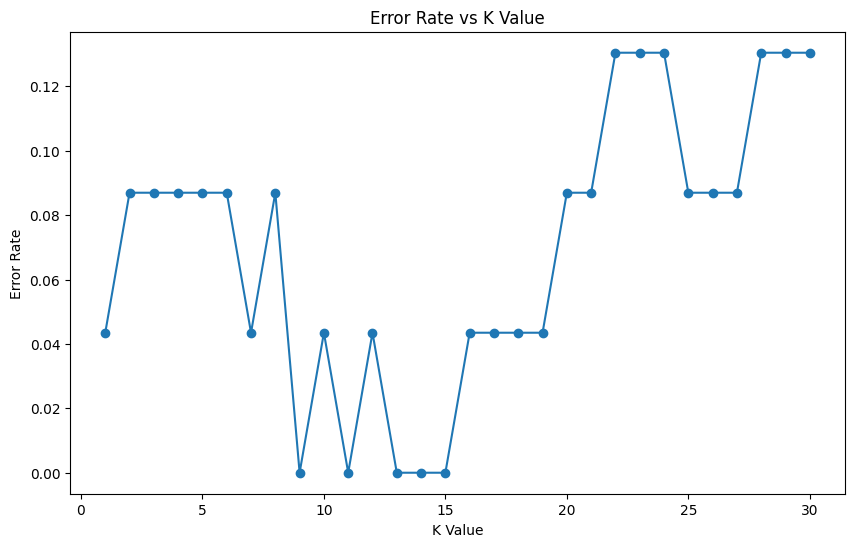

In [11]:
error_rate = []

for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)

plt.figure(figsize=(10,6))

plt.plot(
    range(1,31),
    error_rate,
    marker='o'
)

plt.xlabel("K Value")

plt.ylabel("Error Rate")

plt.title("Error Rate vs K Value")

plt.show()

In [12]:
param_grid = {
    'n_neighbors': list(range(1,31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 14, 'weights': 'uniform'}


In [13]:
best_knn = grid.best_estimator_

In [14]:
y_pred = best_knn.predict(X_test)

y_prob = best_knn.predict_proba(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



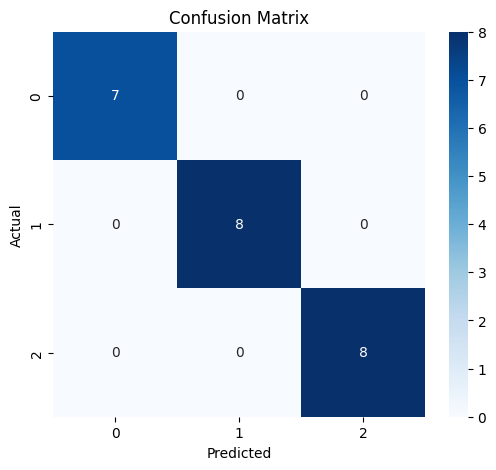

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

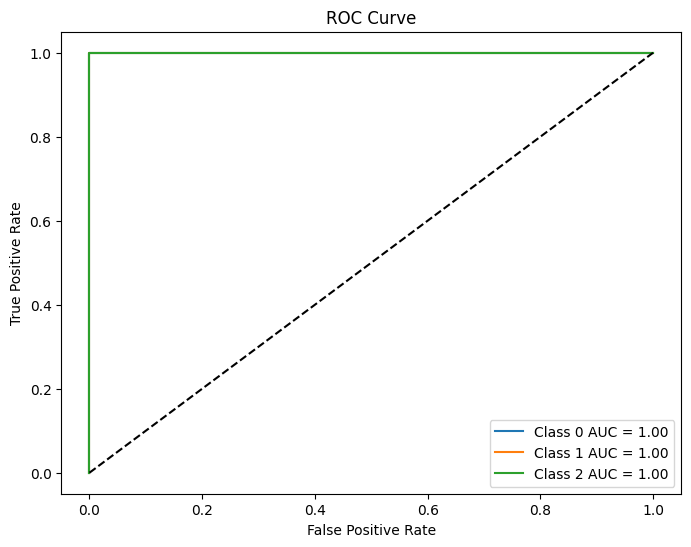

In [18]:
# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])

n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = roc_auc_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} AUC = {roc_auc[i]:.2f}"
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [19]:
sample_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

sample_results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,2,2
3,1,1
4,2,2
5,2,2
6,1,1
7,2,2
8,0,0
9,1,1


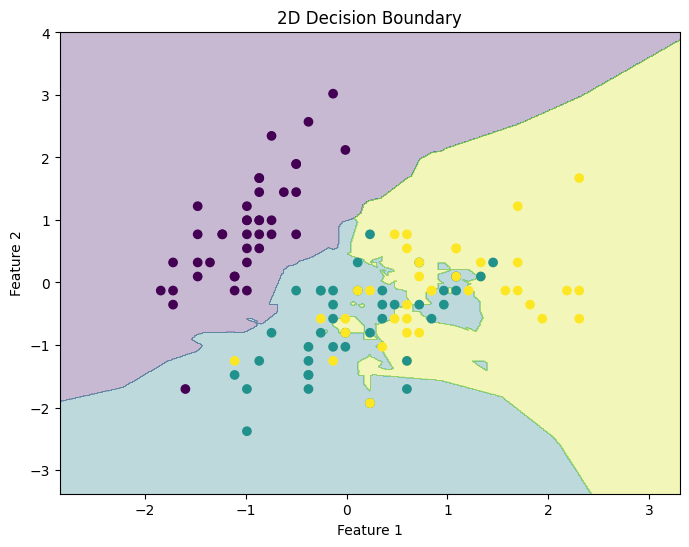

In [20]:
from matplotlib.colors import ListedColormap

# Use first two features only
X_vis = X.iloc[:, :2]

y_vis = y

# Split
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_vis,
    test_size=0.2,
    random_state=42
)

# Scale
scaler_vis = StandardScaler()

X_train_vis = scaler_vis.fit_transform(X_train_vis)

X_test_vis = scaler_vis.transform(X_test_vis)

# Train model
knn_vis = KNeighborsClassifier(n_neighbors=5)

knn_vis.fit(X_train_vis, y_train_vis)

# Meshgrid
x1_min, x1_max = X_train_vis[:,0].min()-1, X_train_vis[:,0].max()+1

x2_min, x2_max = X_train_vis[:,1].min()-1, X_train_vis[:,1].max()+1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.01),
    np.arange(x2_min, x2_max, 0.01)
)

Z = knn_vis.predict(
    np.array([xx1.ravel(), xx2.ravel()]).T
)

Z = Z.reshape(xx1.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx1, xx2, Z, alpha=0.3)

plt.scatter(
    X_train_vis[:,0],
    X_train_vis[:,1],
    c=y_train_vis
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title("2D Decision Boundary")

plt.show()